In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('dataset/train.csv',header=None)

In [3]:
data.columns=['user','song','frequency']

In [4]:
data.head()

,user,song,frequency
0,0,65,24
1,0,102,86
2,0,161,2
3,0,166,1
4,0,176,4


In [5]:
data.isnull().sum()

user         0
song         0
frequency    0
dtype: int64

In [6]:
data.shape

(501519, 3)

In [7]:
print("The number of unique users:           ",data.user.nunique())
print("The number of unique songs:        ",data.song.nunique())

The number of unique users:            937
The number of unique songs:         15580


In [8]:
temp={}
count_songs={}
for i in data.user.unique():
    temp[i]=data[data['user']==i].song.nunique()
count_songs['user']=list(temp.keys())
count_songs['songs_listened']=list(temp.values())

In [9]:
cp_dataframe=pd.DataFrame.from_dict(count_songs)

In [10]:
cp_dataframe_short=cp_dataframe.iloc[:20,:]

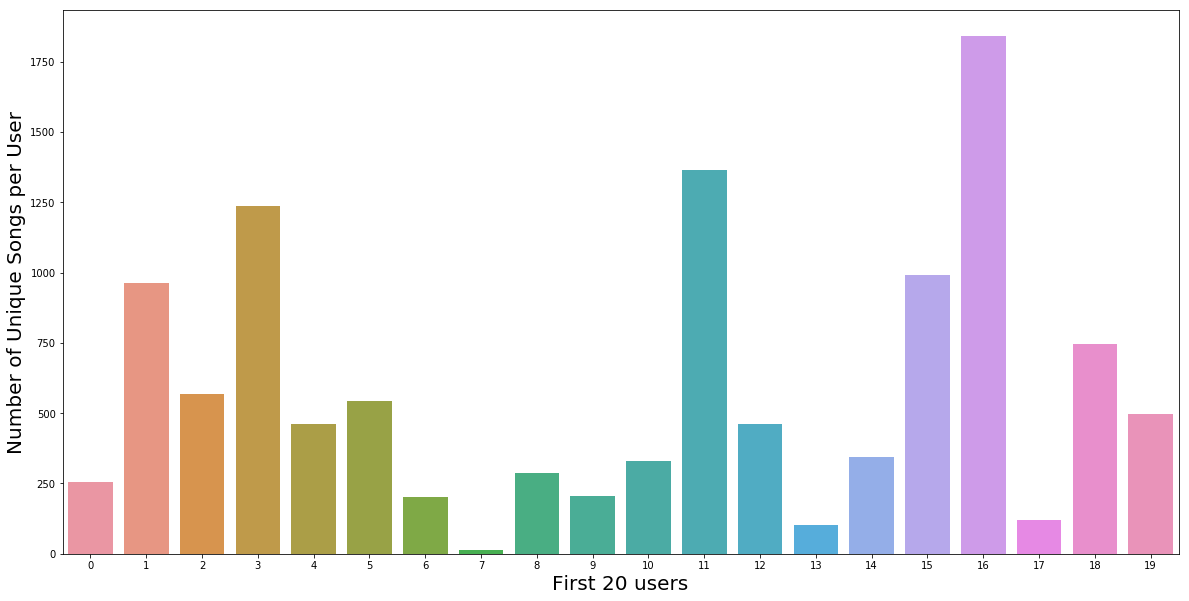

In [11]:
plt.figure(figsize=(20,10))
sns.barplot(cp_dataframe_short.user,cp_dataframe_short.songs_listened)
plt.xlabel('First 20 users', size = 20)
plt.ylabel('Number of Unique Songs per User', size = 20)
plt.show()

### we have users with different mindsets - from user listening to selected number of songs to users listening to wide variety of songs

In [12]:
temp={}
count_freq={}
for i in data.song.unique():
    temp[i]=data[data['song']==i].frequency.sum()
count_freq['song']=list(temp.keys())
count_freq['total_streams']=list(temp.values())

In [13]:
cf_dataframe=pd.DataFrame.from_dict(count_freq)

In [14]:
cf_dataframe = cf_dataframe.sort_values(by='total_streams', ascending=False)

In [15]:
cf_dataframe_short=cf_dataframe.iloc[:10,:]

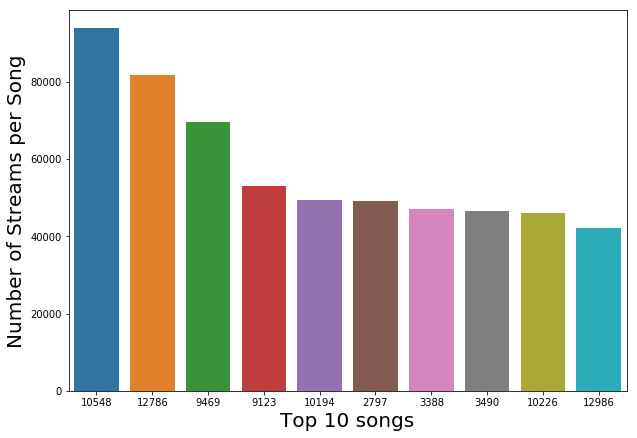

In [16]:
plt.figure(figsize=(10,7))
sns.barplot(cf_dataframe_short['song'],cf_dataframe_short['total_streams'],order=cf_dataframe_short['song'])
plt.xlabel('Top 10 songs', size = 20)
plt.ylabel('Number of Streams per Song', size = 20)
plt.show()

### Here we can see the top 10 songs streamed by  users 

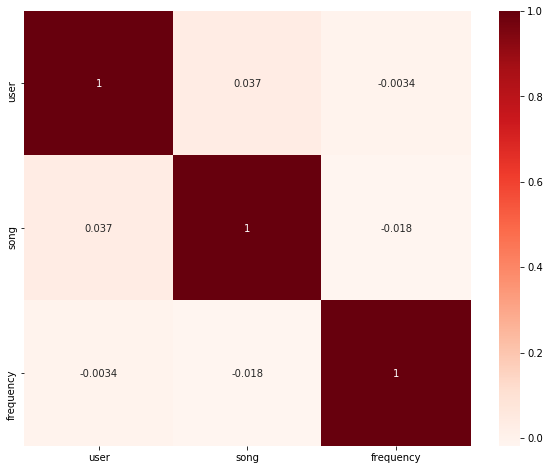

In [134]:
plt.figure(figsize=(10,8))

cor = data.corr()

sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)

plt.show()

### From above correlation coefficient values we can say that there is no significant correaltion between any columns

In [127]:
temp={}
count_user={}
for i in data.song.unique():
    temp[i]=data[data['song']==i].user.nunique()
count_user['song']=list(temp.keys())
count_user['total_users']=list(temp.values())

In [128]:
cu_dataframe=pd.DataFrame.from_dict(count_user)

In [129]:
cu_dataframe = cu_dataframe.sort_values(by='total_users', ascending=False)

In [130]:
cu_dataframe_short=cu_dataframe.iloc[:10,:]

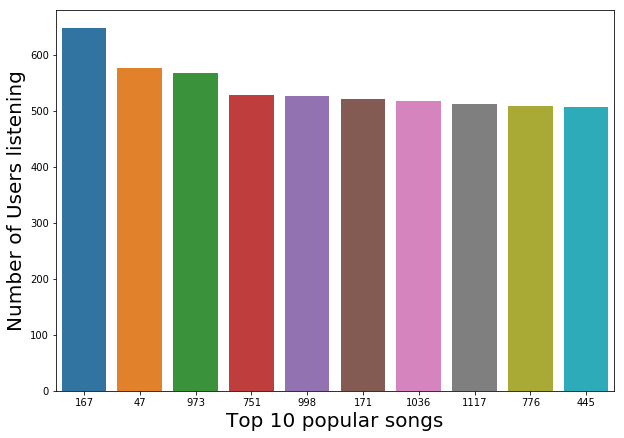

In [131]:
plt.figure(figsize=(10,7))
sns.barplot(cu_dataframe_short['song'],cu_dataframe_short['total_users'],order=cu_dataframe_short['song'])
plt.xlabel('Top 10 popular songs', size = 20)
plt.ylabel('Number of Users listening', size = 20)
plt.show()

In [26]:
df['user'].value_counts(ascending=True)

712       1
139       1
395       1
400       1
239       1
       ... 
694    2910
570    3074
30     3344
342    3890
766    4032
Name: user, Length: 937, dtype: int64

In [27]:
df['song'].unique()

array([   65,   102,   161, ...,  6022,  8548, 14451], dtype=int64)

In [28]:
index=list(df['user'].unique())
columns=list(df['song'].unique())
index=sorted(index)
columns=sorted(columns)
 
util_mat=pd.pivot_table(data=df,values='frequency',index='user',columns='song')

In [29]:
util_mat=util_mat.fillna(0)

In [30]:
util_mat.shape

(937, 15580)

In [31]:
util_mat.head(10)

song,0,1,2,3,4,5,6,7,8,9,...,15658,15659,15660,15661,15662,15663,15664,15665,15666,15667
user,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,48.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### The above matrix is called utility matrix
- Each column is for each user(total 937 users) and each column shows the times a song is listened by a particular user.
- Majority of the matrix is filled with 0's which means that particular song was never listened by user
- All the other non-zero value if user-song pair represent the number of times a user listened to that song

In [34]:
users = data.user.unique()
songs = data.song.unique()

userid2idx = {o:i for i,o in enumerate(users)}
songid2idx = {o:i for i,o in enumerate(songs)}

In [36]:
df['user'] = df['user'].apply(lambda x: userid2idx[x])
df['song'] = df['song'].apply(lambda x: songid2idx[x])
split = np.random.rand(len(df)) < 0.8
train = df[split]
val = df[~split]
print(train.shape , val.shape)

(401959, 3) (99560, 3)


In [37]:
from keras.layers import Dropout, Flatten,Input,Embedding

In [38]:
n_songs=len(data['song'].unique())
n_users=len(data['user'].unique())
n_latent_factors=64

In [106]:
user_input=Input(shape=(1,),name='user_input',dtype='int64')
user_embedding=Embedding(n_users,n_latent_factors,name='user_embedding')(user_input)
user_vec=Flatten(name='FlattenUsers')(user_embedding)
user_vec=Dropout(0.30)(user_vec)

In [107]:
song_input=Input(shape=(1,),name='song_input',dtype='int64')
song_embedding=Embedding(n_songs,n_latent_factors,name='song_embedding')(song_input)
song_vec=Flatten(name='FlattenSongs')(song_embedding)
song_vec=Dropout(0.30)(song_vec)

In [126]:
import keras
from keras.optimizers import Adam
from keras.layers.merge import dot
from keras.models import Model

In [109]:
sim=dot([user_vec,song_vec],name='Simalarity-Dot-Product',axes=1)
model =keras.models.Model([user_input, song_input],sim)

In [110]:
model.compile(optimizer=Adam(lr=1e-4),loss='mse')

In [123]:
train.shape
batch_size=4096
epochs=300

In [124]:
History = model.fit([train.user,train.song],train.frequency, batch_size=batch_size, epochs =epochs, validation_data = ([val.user,val.song],val.frequency), verbose=1)

Epoch 1/300
99/99 [==============================] - 3s 34ms/step - loss: 17718.3516 - val_loss: 17604.5215
Epoch 2/300
99/99 [==============================] - 3s 32ms/step - loss: 17715.4355 - val_loss: 17601.0977
Epoch 3/300
99/99 [==============================] - 3s 28ms/step - loss: 17712.2559 - val_loss: 17597.7168
Epoch 4/300
99/99 [==============================] - 3s 30ms/step - loss: 17706.0938 - val_loss: 17594.3242
Epoch 5/300
99/99 [==============================] - 3s 26ms/step - loss: 17705.2812 - val_loss: 17590.9375
Epoch 6/300
99/99 [==============================] - 3s 31ms/step - loss: 17698.8516 - val_loss: 17587.5469
Epoch 7/300
99/99 [==============================] - 3s 27ms/step - loss: 17694.6094 - val_loss: 17584.1660
Epoch 8/300
99/99 [==============================] - 3s 27ms/step - loss: 17693.9258 - val_loss: 17580.7949
Epoch 9/300
99/99 [==============================] - 3s 27ms/step - loss: 17687.2578 - val_loss: 17577.4727
Epoch 10/300
99/99 [========

Epoch 151/300
99/99 [==============================] - 3s 32ms/step - loss: 17242.5898 - val_loss: 17218.7461
Epoch 152/300
99/99 [==============================] - 3s 29ms/step - loss: 17241.6719 - val_loss: 17216.8945
Epoch 153/300
99/99 [==============================] - 3s 30ms/step - loss: 17235.9941 - val_loss: 17215.0625
Epoch 154/300
99/99 [==============================] - 3s 28ms/step - loss: 17235.7266 - val_loss: 17213.2402
Epoch 155/300
99/99 [==============================] - 3s 28ms/step - loss: 17231.2227 - val_loss: 17211.4160
Epoch 156/300
99/99 [==============================] - 3s 28ms/step - loss: 17230.8809 - val_loss: 17209.5801
Epoch 157/300
99/99 [==============================] - 3s 31ms/step - loss: 17226.7676 - val_loss: 17207.8066
Epoch 158/300
99/99 [==============================] - 3s 26ms/step - loss: 17224.3828 - val_loss: 17206.0273
Epoch 159/300
99/99 [==============================] - 4s 39ms/step - loss: 17222.6074 - val_loss: 17204.2422
Epoch 160/

99/99 [==============================] - 3s 30ms/step - loss: 16906.6426 - val_loss: 17010.9512
Epoch 300/300
99/99 [==============================] - 3s 30ms/step - loss: 16907.4727 - val_loss: 17009.8984


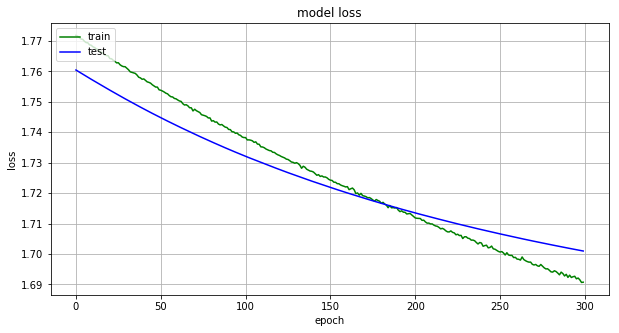

In [125]:
from pylab import rcParams
rcParams['figure.figsize'] = 10, 5
loss=[x/10000 for x in History.history['loss']]
val_loss=[x/10000 for x in History.history['val_loss']]
import matplotlib.pyplot as plt
plt.plot(loss , 'g')
plt.plot(val_loss , 'b')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.grid(True)
plt.show()